In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('sales_data.csv')
df.head()

,OrderID,OrderDate,Region,Salesperson,Product,Category,Units,UnitPrice
0,1023,2025-01-24,North,RAVI KUMAR,Office Chair,Furniture,11.0,6500
1,1134,2025-03-29,North,Ananya Rao,Bookshelf,Furniture,2.0,4200
2,1115,2025-03-18,West,Rohan Shah,Notebook Set,Stationery,12.0,350
3,1077,2025-06-08,South,Divya Sharma,Office Chair,Furniture,3.0,6500
4,1009,2025-06-04,East,Sneha Das,Bookshelf,Furniture,9.0,4200


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      183 non-null    int64  
 1   OrderDate    183 non-null    object 
 2   Region       183 non-null    object 
 3   Salesperson  183 non-null    object 
 4   Product      183 non-null    object 
 5   Category     183 non-null    object 
 6   Units        174 non-null    float64
 7   UnitPrice    183 non-null    int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 11.6+ KB


,OrderID,Units,UnitPrice
count,183.000000,174.000000,183.000000
mean,1089.874317,6.534483,10835.939891
std,52.060621,3.580045,19291.238526
min,1001.000000,1.000000,120.000000
25%,1045.500000,3.000000,350.000000
50%,1090.000000,7.000000,2999.000000
75%,1134.500000,10.000000,15500.000000
max,1180.000000,12.000000,68000.000000


In [ ]:
df['Region'] = df['Region'].str.strip().str.title()
df['Salesperson'] = df['Salesperson'].str.strip().str.title()
df['Product'] = df['Product'].str.strip().str.title()
df['Category'] = df['Category'].str.strip().str.title()

In [ ]:
df['Units'] = df['Units'].fillna(0)

In [ ]:
print("Before:", len(df))
df = df.drop_duplicates()
print("After:", len(df))

Before: 183
After: 180


In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df['Sales'] = df['Units'] * df['UnitPrice']

In [ ]:
total_sales = df['Sales'].sum()
total_units = df['Units'].sum()
total_orders = df['OrderID'].nunique()
avg_order_value = total_sales / total_orders
print(f"Total Sales: {total_sales:,.0f}")
print(f"Total Units: {total_units:,.0f}")
print(f"Total Orders: {total_orders}")
print(f"Avg Order Value: {avg_order_value:,.0f}")

Total Sales: 9,053,158
Total Units: 1,129
Total Orders: 180
Avg Order Value: 50,295


In [ ]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(sales_by_region)

Region
West     2933144.0
North    2680273.0
South    2042877.0
East     1396864.0
Name: Sales, dtype: float64


In [ ]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(sales_by_category)

Category
Electronics    6296288.0
Furniture      2683000.0
Stationery       73870.0
Name: Sales, dtype: float64


In [ ]:
sales_by_salesperson = df.groupby('Salesperson')['Sales'].sum().sort_values(ascending=False)
print(sales_by_salesperson)

Salesperson
Ravi Kumar      1728152.0
Priya Mehta     1512305.0
Rohan Shah      1420839.0
Karthik Iyer    1391064.0
Ananya Rao       952121.0
Amit Ghosh       895307.0
Divya Sharma     651813.0
Sneha Das        501557.0
Name: Sales, dtype: float64


In [ ]:
top_region = sales_by_region.idxmax()
print(f"Top Region: {top_region}")

Top Region: West


In [ ]:
top_salesperson = sales_by_salesperson.idxmax()
print(f"Top Salesperson: {top_salesperson}")

Top Salesperson: Ravi Kumar


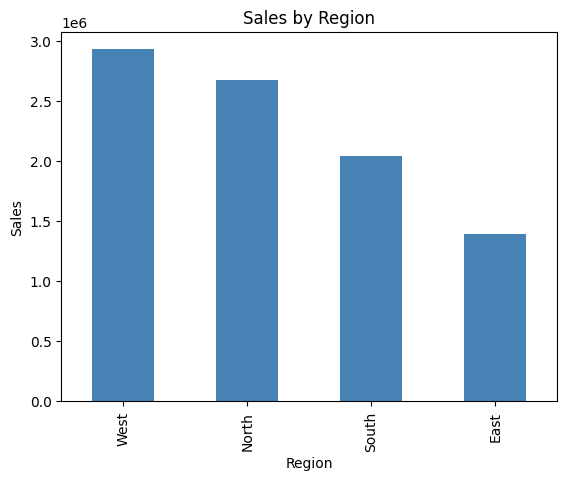

In [ ]:
sales_by_region.plot(kind='bar', color='steelblue')
plt.title('Sales by Region')
plt.ylabel('Sales')
plt.xlabel('Region')
plt.show()

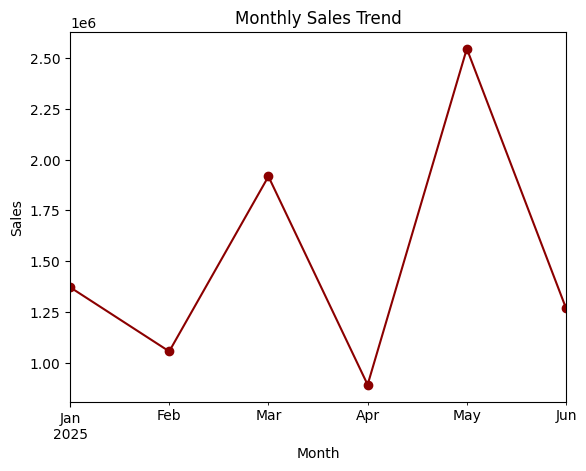

In [ ]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Month'] = df['OrderDate'].dt.to_period('M')
sales_by_month = df.groupby('Month')['Sales'].sum()
sales_by_month.plot(kind='line', marker='o', color='darkred')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.xlabel('Month')
plt.show()

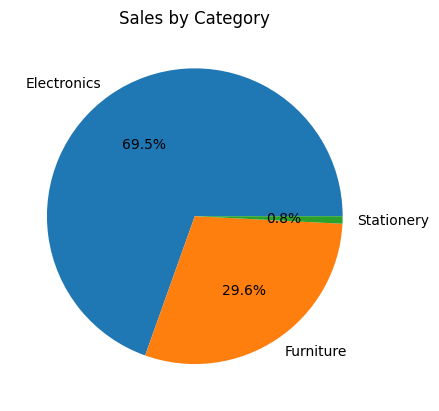

In [ ]:
sales_by_category = df.groupby('Category')['Sales'].sum()
sales_by_category.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Category')
plt.ylabel('')
plt.show()

In [61]:
print(df[df['Units'] <= 0])
print(df[df['UnitPrice'] <= 0])
print(df[df['OrderDate'] > pd.Timestamp.today()])
print(df['Region'].unique())
print(df['Category'].unique())

     OrderID  OrderDate Region   Salesperson            Product     Category  \
24      1047 2025-03-13   West   Priya Mehta     Wireless Mouse  Electronics   
35      1116 2025-05-20  South  Karthik Iyer      Standing Desk    Furniture   
109     1162 2025-01-16  North    Ravi Kumar      Standing Desk    Furniture   
118     1093 2025-06-20   West   Priya Mehta  Bluetooth Speaker  Electronics   
137     1070 2025-04-19   East     Sneha Das      Laptop Pro 14  Electronics   
145     1024 2025-02-10   West   Priya Mehta       27In Monitor  Electronics   
172     1139 2025-06-06   West    Rohan Shah      Laptop Pro 14  Electronics   
174     1001 2025-06-13  North    Ravi Kumar      A4 Paper Ream   Stationery   

     Units  UnitPrice  Sales    Month  
24     0.0        799    0.0  2025-03  
35     0.0      15500    0.0  2025-05  
109    0.0      15500    0.0  2025-01  
118    0.0       2999    0.0  2025-06  
137    0.0      68000    0.0  2025-04  
145    0.0      18500    0.0  2025-02  

In [62]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
outliers[['OrderID', 'Product', 'Units', 'UnitPrice', 'Sales']]

Number of outliers: 22


,OrderID,Product,Units,UnitPrice,Sales
23,1165,Laptop Pro 14,4.0,68000,272000.0
45,1003,Laptop Pro 14,2.0,68000,136000.0
50,1088,Laptop Pro 14,9.0,68000,612000.0
57,1055,Laptop Pro 14,9.0,68000,612000.0
78,1017,Laptop Pro 14,4.0,68000,272000.0
82,1084,Laptop Pro 14,2.0,68000,136000.0
88,1164,Laptop Pro 14,7.0,68000,476000.0
90,1050,Laptop Pro 14,3.0,68000,204000.0
96,1059,Standing Desk,11.0,15500,170500.0
100,1150,Standing Desk,12.0,15500,186000.0


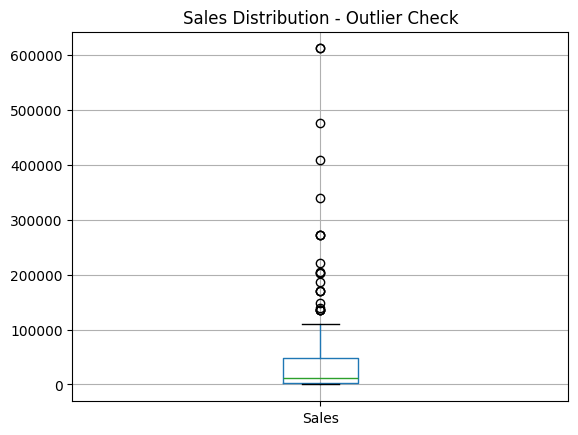

In [64]:
df.boxplot(column='Sales')
plt.title('Sales Distribution - Outlier Check')
plt.show()

In [65]:
outliers[['Product', 'Category', 'Units', 'UnitPrice']]

,Product,Category,Units,UnitPrice
23,Laptop Pro 14,Electronics,4.0,68000
45,Laptop Pro 14,Electronics,2.0,68000
50,Laptop Pro 14,Electronics,9.0,68000
57,Laptop Pro 14,Electronics,9.0,68000
78,Laptop Pro 14,Electronics,4.0,68000
82,Laptop Pro 14,Electronics,2.0,68000
88,Laptop Pro 14,Electronics,7.0,68000
90,Laptop Pro 14,Electronics,3.0,68000
96,Standing Desk,Furniture,11.0,15500
100,Standing Desk,Furniture,12.0,15500


In [66]:
correlation = df['Units'].corr(df['UnitPrice'])
print(f"Correlation between Units and UnitPrice: {correlation:.2f}")

Correlation between Units and UnitPrice: -0.26


In [67]:
numeric_cols = df[['Units', 'UnitPrice', 'Sales']]
corr_matrix = numeric_cols.corr()
print(corr_matrix)

              Units  UnitPrice     Sales
Units      1.000000  -0.256070  0.130935
UnitPrice -0.256070   1.000000  0.727823
Sales      0.130935   0.727823  1.000000


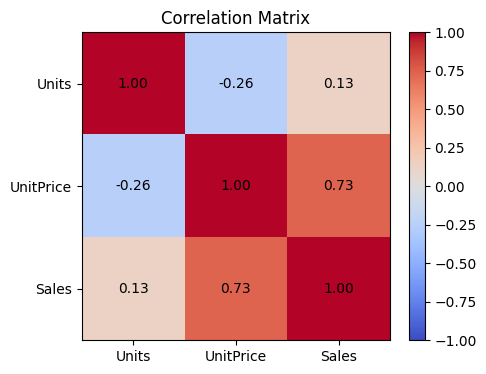

In [69]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center')
plt.colorbar(im)
plt.title('Correlation Matrix')
plt.show()

In [73]:
monthly_change = sales_by_month.pct_change() * 100
print(monthly_change.round(1))

Month
2025-01      NaN
2025-02    -23.0
2025-03     81.5
2025-04    -53.5
2025-05    185.3
2025-06    -50.2
Freq: M, Name: Sales, dtype: float64


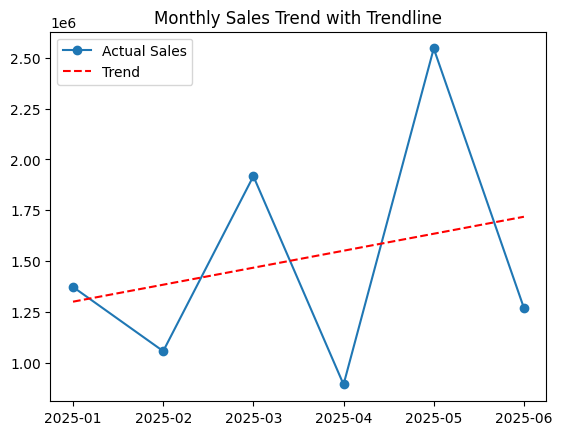

In [71]:
import numpy as np
x = np.arange(len(sales_by_month))
y = sales_by_month.values
z = np.polyfit(x, y, 1)
trend_line = np.poly1d(z)
plt.plot(x, y, marker='o', label='Actual Sales')
plt.plot(x, trend_line(x), linestyle='--', color='red', label='Trend')
plt.xticks(x, sales_by_month.index.astype(str))
plt.title('Monthly Sales Trend with Trendline')
plt.legend()
plt.show()

In [74]:
print("Mean Sales:", df['Sales'].mean())
print("Median Sales:", df['Sales'].median())
print("Mode Sales:", df['Sales'].mode()[0])

Mean Sales: 50295.322222222225
Median Sales: 11996.0
Mode Sales: 0.0


In [75]:
print("Std Dev:", df['Sales'].std())
print("Variance:", df['Sales'].var())

Std Dev: 95214.82812303421
Variance: 9065863494.498945


In [76]:
df['Sales'].quantile([0.25, 0.5, 0.75])

,Sales
0.25,2000.0
0.50,11996.0
0.75,47475.0


In [77]:
df.groupby('Region')['Sales'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
Region,,,,
East,30366.608696,12544.0,45882.636915,46
North,59561.622222,9588.0,121131.783152,45
South,49826.268293,19500.0,69013.719053,41
West,61107.166667,13797.5,118875.772152,48
